<h1>Import Libraries</h1>



In [101]:
# Install required packages if not available
import sys
!{sys.executable} -m pip install kagglehub pandas numpy matplotlib seaborn plotly

print("Packages installed successfully!")

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Data loading utilities
import zipfile
import os
import kagglehub

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

# Recommendation system libraries
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error

# Install implicit if not available
import subprocess
import sys

print("Checking for implicit library...")
try:
    import implicit
    print("✅ implicit library is already available!")
except ImportError:
    print("❌ implicit library not found. Installing...")
    try:
        # Try installing with pip
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'implicit'])
        print("✅ implicit library installed via pip!")
        
        # Try importing again
        import implicit
        print("✅ implicit library imported successfully!")
        
    except Exception as e:
        print(f"❌ Installation failed: {e}")
        print("💡 Please try manually installing with: pip install implicit")
        print("💡 Or try: conda install -c conda-forge implicit")
        raise ImportError("Could not install implicit library")



Packages installed successfully!
Libraries imported successfully!
Checking for implicit library...
✅ implicit library is already available!


<h1>Load the Data</h1>
<p>Takes about 1 minute</p>

In [102]:
# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download("andrewmvd/spotify-playlists")
print(f"Dataset downloaded to: {dataset_path}")

# Find the CSV file (it might be in a ZIP)
csv_files = []
zip_files = []

for file in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, file)
    if file.lower().endswith('.csv'):
        csv_files.append(file_path)
    elif file.lower().endswith('.zip'):
        zip_files.append(file_path)

print(f"Found {len(csv_files)} CSV files and {len(zip_files)} ZIP files")

# Load the data with robust error handling
df = None

if csv_files:
    # Direct CSV file found
    csv_file = csv_files[0]
    print(f"Loading CSV file: {csv_file}")
    try:
        df = pd.read_csv(
            csv_file,
            encoding='iso-8859-1',  # Permissive encoding
            sep=',',
            quotechar='"',
            escapechar='\\',
            engine='python',
            on_bad_lines='skip'
        )
    except Exception as e:
        print(f"Error loading CSV directly: {e}")

elif zip_files:
    # Extract and load from ZIP file
    zip_file = zip_files[0]
    print(f"Extracting from ZIP file: {zip_file}")
    try:
        with zipfile.ZipFile(zip_file, 'r') as z:
            csv_name = next((n for n in z.namelist() if n.lower().endswith('.csv')), None)
            if csv_name:
                print(f"Found CSV in ZIP: {csv_name}")
                with z.open(csv_name) as f:
                    df = pd.read_csv(
                        f,
                        encoding='iso-8859-1',
                        sep=',',
                        quotechar='"',
                        escapechar='\\',
                        engine='python',
                        on_bad_lines='skip'
                    )
            else:
                print("No CSV file found in ZIP archive")
    except Exception as e:
        print(f"Error extracting from ZIP: {e}")

if df is not None:
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
else:
    print("Failed to load dataset")

# Clean column names - remove extra spaces and quotes
if df is not None:
    print("Cleaning column names...")
    print("Before:", list(df.columns))
    
    # Strip spaces and quotes from column names
    df.columns = [col.strip().strip('"') for col in df.columns]
    
    print("After:", list(df.columns))
    print("Column names cleaned successfully!")

# Basic dataset information
print("Dataset Info:")
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Key statistics
stats = {
    'Total Records': df.shape[0],
    'Unique Users': df['user_id'].nunique() if 'user_id' in df.columns else 'N/A',
    'Unique Artists': df['artistname'].nunique() if 'artistname' in df.columns else 'N/A',
    'Unique Tracks': df['trackname'].nunique() if 'trackname' in df.columns else 'N/A',
    'Unique Playlists': df['playlistname'].nunique() if 'playlistname' in df.columns else 'N/A'
}

for key, value in stats.items():
    print(f"{key}: {value:,}" if isinstance(value, int) else f"{key}: {value}")

    


Dataset downloaded to: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1
Found 1 CSV files and 0 ZIP files
Loading CSV file: C:\Users\mstan\.cache\kagglehub\datasets\andrewmvd\spotify-playlists\versions\1\spotify_dataset.csv
Dataset loaded successfully!
Shape: (12791243, 4)
Columns: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
Cleaning column names...
Before: ['user_id', ' "artistname"', ' "trackname"', ' "playlistname"']
After: ['user_id', 'artistname', 'trackname', 'playlistname']
Column names cleaned successfully!
Dataset Info:
Number of rows: 12,791,243
Number of columns: 4
Memory usage: 3390.16 MB

Column data types:
user_id         object
artistname      object
trackname       object
playlistname    object
dtype: object

Missing values:
user_id             0
artistname      33536
trackname          88
playlistname       41
dtype: int64
Total Records: 12,791,243
Unique Users: 15,910
Unique Artists: 287,438
Unique Tracks: 1,999,879
U

<h1>Visualize the data </h1>

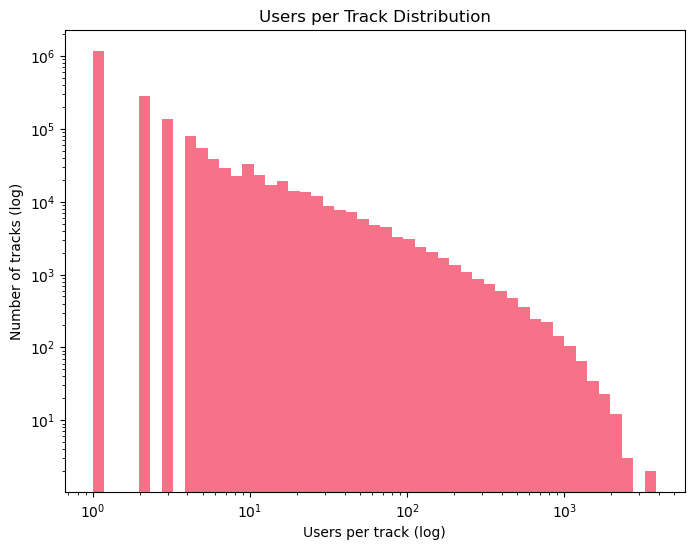

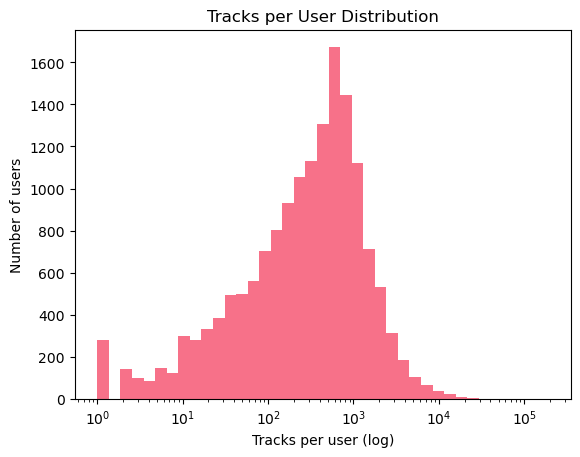

In [103]:
# users_per_track

users_per_track = (
    df.groupby("trackname")["user_id"]
      .nunique()
      .values
)

users_per_track = np.array(users_per_track)

bins = np.logspace(
    np.log10(users_per_track.min()),
    np.log10(users_per_track.max()),
    50
)

plt.figure(figsize=(8, 6))
plt.hist(users_per_track, bins=bins)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Users per track (log)')
plt.ylabel('Number of tracks (log)')
plt.title('Users per Track Distribution')

plt.show()

# tracks_per_user
tracks_per_user = (
    df.groupby("user_id")["trackname"]
      .nunique()
      .values
)

bins = np.logspace(
    np.log10(tracks_per_user.min()),
    np.log10(tracks_per_user.max()),
    40
)

plt.figure()
plt.hist(tracks_per_user, bins=bins)
plt.xscale("log")
plt.xlabel("Tracks per user (log)")
plt.ylabel("Number of users")
plt.title("Tracks per User Distribution")
plt.show()

<h1>preprocessing</h1>

In [104]:
# Load existing train/validation split files (FAST VERSION)
def load_existing_split(output_dir='./data_splits/'):
    """
    Load previously created train/validation split files
    Use this instead of recreating the split to save time
    """
    import os
    
    train_file = os.path.join(output_dir, 'train_data.csv')
    val_file = os.path.join(output_dir, 'validation_data.csv')
    
    print("📖 Loading existing train/validation split files...")
    
    # Check if files exist
    if not os.path.exists(train_file):
        print(f"❌ Train file not found: {train_file}")
        print("💡 You need to run the split creation cell first!")
        return None, None
    
    if not os.path.exists(val_file):
        print(f"❌ Validation file not found: {val_file}")
        print("💡 You need to run the split creation cell first!")
        return None, None
    
    # Load the files
    print(f"📁 Loading train data from: {train_file}")
    df_train = pd.read_csv(train_file)
    
    print(f"📁 Loading validation data from: {val_file}")
    df_validation = pd.read_csv(val_file)
    
    # Display info about loaded data
    print(f"\n✅ Successfully loaded existing split:")
    print(f"  📊 Train set: {len(df_train):,} interactions from {df_train['user_id'].nunique():,} users")
    print(f"  📊 Validation set: {len(df_validation):,} interactions from {df_validation['user_id'].nunique():,} users")
    print(f"  📊 Train tracks: {df_train['trackname'].nunique():,} unique tracks")
    print(f"  📊 Validation tracks: {df_validation['trackname'].nunique():,} unique tracks")
    
    # Check data integrity
    common_users = set(df_train['user_id'].unique()).intersection(set(df_validation['user_id'].unique()))
    print(f"  🔗 Users in both sets: {len(common_users):,} (this is normal)")
    
    return df_train, df_validation

# 🚀 LOAD EXISTING SPLIT (FAST!)
print("🚀 LOADING EXISTING TRAIN/VALIDATION SPLIT")
print("="*50)

df_train, df_validation = load_existing_split()

if df_train is not None and df_validation is not None:
    print(f"\n🎉 Ready to proceed with model training and validation!")
    print(f"💡 No need to recreate the split - using existing files for speed")
else:
    print(f"\n⚠️  Could not load existing split files")
    print(f"💡 Run the 'Create train/validation split' cell first to generate the files")

🚀 LOADING EXISTING TRAIN/VALIDATION SPLIT
📖 Loading existing train/validation split files...
📁 Loading train data from: ./data_splits/train_data.csv
📁 Loading validation data from: ./data_splits/validation_data.csv

✅ Successfully loaded existing split:
  📊 Train set: 10,226,828 interactions from 15,910 users
  📊 Validation set: 2,247,978 interactions from 15,518 users
  📊 Train tracks: 2,250,904 unique tracks
  📊 Validation tracks: 665,365 unique tracks
  🔗 Users in both sets: 15,518 (this is normal)

🎉 Ready to proceed with model training and validation!
💡 No need to recreate the split - using existing files for speed


In [105]:
# filter out users and items with insufficient interactions

def filter_global_universe(df, min_tracks=5, min_users=5):
    """
    Applied to the FULL dataset to ensure every user/item in the 
    validation set also exists in the training set with sufficient signal.
    """
    print(f"Starting total records: {len(df):,}")
    
    # Iterative filtering to ensure both conditions are met (K-core)
    while True:
        starting_size = len(df)
        df = df.groupby('trackname').filter(lambda x: len(x) >= min_users)
        df = df.groupby('user_id').filter(lambda x: len(x) >= min_tracks)
        if len(df) == starting_size:
            break
            
    print(f"Filtered total records: {len(df):,}")
    return df

df_train = filter_global_universe(df_train, min_tracks=5, min_users=5)
df_validation = filter_global_universe(df_validation, min_tracks=5, min_users=5)    

Starting total records: 10,226,828
Filtered total records: 7,309,402
Starting total records: 2,247,978
Filtered total records: 1,334,980


In [106]:


from scipy.sparse import csr_matrix
from implicit.nearest_neighbours import bm25_weight

def build_training_matrix(df_train):
    """
    Creates the weighted matrix for the ALS model to learn from.
    """
    # 1. Aggregate and Log Scale
    counts = df_train.groupby(['user_id', 'trackname']).size().reset_index(name='c')
    counts['w'] = np.log1p(counts['c'])
    
    # 2. Map to Categorical (Crucial for matrix indexing)
    counts['user_id'] = counts['user_id'].astype('category')
    counts['trackname'] = counts['trackname'].astype('category')
    
    # 3. Create Sparse Matrix
    train_matrix = csr_matrix(
        (counts['w'].astype(np.float32), 
        (counts['user_id'].cat.codes, counts['trackname'].cat.codes))
    )
    
    # 4. Apply BM25 Weighting
    # This happens ONLY on training data to avoid popularity leakage
    weighted_train = bm25_weight(train_matrix, K1=1.2, B=0.75).tocsr()
    
    # Keep these to align the validation set later
    user_categories = counts['user_id'].cat.categories
    track_categories = counts['trackname'].cat.categories
    
    return weighted_train, user_categories, track_categories

train_processed, u_cat, t_cat = build_training_matrix(df_train)
print("Training matrix built successfully!")


Training matrix built successfully!


In [ ]:
"""

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from implicit.nearest_neighbours import bm25_weight

def build_artist_boosted_matrix(df_train, boost_factor=0.5):
    
    #Creates a User-Item matrix where weights are boosted by Artist Affinity.
    
    print("Step 1: Calculating Track-Artist mapping...")
    # Group interactions by User and Track
    interactions = df_train.groupby(['user_id', 'trackname', 'artistname']).size().reset_index(name='count')
    
    print("Step 2: Calculating User-Artist affinity...")
    # How many tracks by this artist does the user have?
    user_artist_counts = df_train.groupby(['user_id', 'artistname']).size().reset_index(name='artist_count')
    
    # Merge artist affinity back into interaction data
    interactions = interactions.merge(user_artist_counts, on=['user_id', 'artistname'], how='left')
    
    print("Step 3: Applying Artist Boost...")
    # Log scaling original counts
    interactions['log_count'] = np.log1p(interactions['count'])
    
    # Apply Boost: 1.0 (baseline) + (Artist Count scaled)
    # We log scale the artist count so a user with 100 songs by an artist 
    # doesn't completely drown out a user with 5.
    interactions['boosted_weight'] = interactions['log_count'] * (1 + (boost_factor * np.log1p(interactions['artist_count'])))
    
    print("Step 4: Building Sparse Matrix...")
    # Map to categories for integer indexing
    interactions['user_id'] = interactions['user_id'].astype('category')
    interactions['trackname'] = interactions['trackname'].astype('category')
    
    u_cat = interactions['user_id'].cat.categories
    t_cat = interactions['trackname'].cat.categories
    
    matrix = csr_matrix(
        (interactions['boosted_weight'].astype(np.float32), 
        (interactions['user_id'].cat.codes, interactions['trackname'].cat.codes))
    )
    
    # Apply BM25 on top of the boosted weights
    print("Step 5: Final BM25 weighting...")
    final_matrix = bm25_weight(matrix, K1=1.5, B=0.75).tocsr()
    
    return final_matrix, u_cat, t_cat

# Execute
train_processed, u_cat, t_cat = build_artist_boosted_matrix(df_train)

"""

Step 1: Calculating Track-Artist mapping...
Step 2: Calculating User-Artist affinity...
Step 3: Applying Artist Boost...
Step 4: Building Sparse Matrix...
Step 5: Final BM25 weighting...


In [107]:
def build_validation_matrix(df_val, user_categories, track_categories):
    """
    Creates a binary/raw matrix for validation. 
    Matches IDs to the training matrix.
    """
    # Map validation IDs to the training category codes
    # Any item in Val NOT in Train will be dropped (NaN)
    user_map = {name: i for i, name in enumerate(user_categories)}
    track_map = {name: i for i, name in enumerate(track_categories)}
    
    df_val['u_idx'] = df_val['user_id'].map(user_map)
    df_val['t_idx'] = df_val['trackname'].map(track_map)
    
    # Drop records that couldn't be mapped (if any)
    df_val = df_val.dropna(subset=['u_idx', 't_idx'])
    
    val_matrix = csr_matrix(
        (np.ones(len(df_val), dtype=np.float32), 
        (df_val['u_idx'].astype(int), df_val['t_idx'].astype(int))),
        shape=(len(user_categories), len(track_categories))
    )
    
    return val_matrix

validation = build_validation_matrix(df_validation, u_cat, t_cat)
print("Validation matrix built successfully!")

Validation matrix built successfully!


<h1>Build the Model</h1>

In [108]:
import implicit
import numpy as np
import random
from implicit.evaluation import AUC_at_k

# Initialize the ALS model
model = implicit.als.AlternatingLeastSquares(
    factors=100, 
    regularization=0.01, 
    iterations=15,
    random_state=42
)

# CORRECTED: Train the model with proper orientation
# The implicit library expects [users x items] format for fitting
# Our train_processed is already in [users x items] format, so don't transpose!
print("Training model with correct orientation...")
print(f"Training matrix shape: {train_processed.shape} (users x items)")

model.fit(train_processed)  # DON'T transpose - use the original matrix

print(f"✅ Model trained successfully!")
print(f"Model user factors: {model.user_factors.shape[0]} users")
print(f"Model item factors: {model.item_factors.shape[0]} items")

Training model with correct orientation...
Training matrix shape: (14878, 354258) (users x items)


  0%|          | 0/15 [00:00<?, ?it/s]

✅ Model trained successfully!
Model user factors: 14878 users
Model item factors: 354258 items


In [109]:
import numpy as np
import pandas as pd
from implicit.evaluation import AUC_at_k
import time

def evaluate_recommender_final(model, train_matrix, val_matrix, n_samples=1000):
    """
    Final optimized evaluation:
    1. AUC_at_k for global ranking performance.
    2. MPR with training-item masking for discovery performance.
    """
    print(f"Starting Evaluation (Users: {train_matrix.shape[0]}, Items: {train_matrix.shape[1]})")
    
    # --- 1. GLOBAL AUC ---
    # Transpose train_matrix because AUC_at_k expects [Items x Users]
    start_auc = time.time()
    auc_score = AUC_at_k(model, train_matrix.T, val_matrix, K=100)
    print(f"✅ AUC calculation complete ({time.time() - start_auc:.2f}s)")

    # --- 2. MEAN PERCENTILE RANK (MPR) ---
    print(f"Calculating MPR (Sampling {n_samples} users)...")
    
    # Find all users who have data in the validation set
    val_user_indices = np.unique(val_matrix.nonzero()[0])
    
    # Filter out users who might be outside the model's factor range
    val_user_indices = val_user_indices[val_user_indices < model.user_factors.shape[0]]
    
    # Randomly sample to keep computation efficient
    if len(val_user_indices) > n_samples:
        sample_users = np.random.choice(val_user_indices, size=n_samples, replace=False)
    else:
        sample_users = val_user_indices

    ranking_scores = []
    num_items = train_matrix.shape[1]

    for user_id in sample_users:
        # Get items the user has in validation (the "answers")
        actual_liked_val = val_matrix[user_id].indices
        if len(actual_liked_val) == 0:
            continue
            
        # Get items the user ALREADY had in training (to mask them)
        already_liked_train = train_matrix[user_id].indices
        
        # Calculate raw scores for ALL items for this user
        # Dot product: (1 x Factors) * (Factors x Items) = (1 x Items)
        user_vec = model.user_factors[user_id]
        all_scores = user_vec @ model.item_factors.T
        
        # IMPORTANT: Mask training items by setting their score to -infinity
        # This ensures we are measuring the rank among NEW songs only.
        all_scores[already_liked_train] = -np.inf
        
        for track_id in actual_liked_val:
            if track_id >= num_items:
                continue
                
            test_score = all_scores[track_id]
            
            # Rank = how many items have a higher score than our validation track
            # Lower rank is better (0 = #1 recommendation)
            rank = np.sum(all_scores > test_score)
            
            # Percentile Rank (0.0 to 1.0)
            percentile_rank = rank / num_items
            ranking_scores.append(percentile_rank)

    mpr_score = np.mean(ranking_scores) if ranking_scores else 1.0
    
    print(f"✅ MPR calculation complete.")
    return auc_score, mpr_score

# --- EXECUTION ---
print("\n" + "="*40)
print("🚀 RUNNING FINAL EVALUATION")
print("="*40)

try:
    auc, mpr = evaluate_recommender_final(model, train_processed, validation)
    
    print("\n" + "📊 FINAL METRICS")
    print("-" * 20)
    print(f"AUC Score: {auc:.4f}")
    print(f"MPR Score: {mpr:.4f}")
    print("-" * 20)
    
    # Summary Analysis
    if auc < 0.6 and mpr < 0.01:
        print("\n💡 ANALYSIS: Your model is likely suffering from 'Popularity Bias'.")
        print("It is very good at ranking hits (low MPR), but struggles to distinguish")
        print("between personalized niche tracks (low AUC).")
    elif auc > 0.7:
        print("\n💡 ANALYSIS: Your model has strong personalization!")
        
except Exception as e:
    print(f"Error during evaluation: {e}")


🚀 RUNNING FINAL EVALUATION
Starting Evaluation (Users: 14878, Items: 354258)


  0%|          | 0/13319 [00:00<?, ?it/s]

✅ AUC calculation complete (23.90s)
Calculating MPR (Sampling 1000 users)...
✅ MPR calculation complete.

📊 FINAL METRICS
--------------------
AUC Score: 0.5813
MPR Score: 0.2543
--------------------


In [110]:
results = []
for f in [100, 200, 400]:
    for r in [0.01, 0.1]:
        print(f"Testing: Factors={f}, Reg={r}")
        
        test_model = implicit.als.AlternatingLeastSquares(
            factors=f, 
            regularization=r, 
            iterations=20, # Increased iterations for better convergence
            random_state=42
        )
        
        test_model.fit(train_processed)  # FIXED: Don't transpose - same as original model
        
        # Use your updated evaluation function
        auc, mpr = evaluate_recommender_final(test_model, train_processed, validation, n_samples=500)
        results.append({'factors': f, 'reg': r, 'auc': auc, 'mpr': mpr})

# Display results to find the "Sweet Spot"
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='auc', ascending=False))

Testing: Factors=100, Reg=0.01


  0%|          | 0/20 [00:00<?, ?it/s]

Starting Evaluation (Users: 14878, Items: 354258)


  0%|          | 0/13319 [00:00<?, ?it/s]

✅ AUC calculation complete (23.45s)
Calculating MPR (Sampling 500 users)...
✅ MPR calculation complete.
Testing: Factors=100, Reg=0.1


...

✅ AUC calculation complete (69.33s)
Calculating MPR (Sampling 500 users)...
✅ MPR calculation complete.
Testing: Factors=400, Reg=0.1


  0%|          | 0/20 [00:00<?, ?it/s]

Starting Evaluation (Users: 14878, Items: 354258)


  0%|          | 0/13319 [00:00<?, ?it/s]

✅ AUC calculation complete (67.53s)
Calculating MPR (Sampling 500 users)...
✅ MPR calculation complete.
   factors   reg       auc       mpr
5      400  0.10  0.606570  0.237191
4      400  0.01  0.606564  0.273534
3      200  0.10  0.596790  0.243296
2      200  0.01  0.596788  0.277728
0      100  0.01  0.581283  0.232713
1      100  0.10  0.581269  0.230806


In [111]:
import pandas as pd
import numpy as np

def diagnostic_popularity_trap(model, train_matrix, track_map, n_users=5, n_recs=10):
    print(f"--- Diagnostic: Top {n_recs} Recs for {n_users} Random Users ---")
    
    user_indices = np.random.choice(train_matrix.shape[0], size=n_users, replace=False)
    all_recs = []
    
    for i, user_id in enumerate(user_indices):
        # Get recommendations (filter_already_liked_items=True is important here)
        ids, scores = model.recommend(user_id, train_matrix[user_id], N=n_recs, filter_already_liked_items=True)
        
        # Map IDs to names
        rec_names = [track_map[idx] for idx in ids]
        all_recs.append(set(rec_names))
        
        print(f"\nUser {user_id} Top 3:")
        for j in range(3):
            print(f"  {j+1}. {rec_names[j]} (Score: {scores[j]:.3f})")

    # Calculate Overlap
    # Intersection of all sets
    common_items = set.intersection(*all_recs)
    
    print("\n" + "="*30)
    print(f"Common items across all {n_users} users: {len(common_items)}")
    if len(common_items) > (n_recs * 0.5):
        print("🚨 VERDICT: POPULARITY TRAP")
        print("The model is recommending the same 'Hits' to everyone regardless of taste.")
    elif len(common_items) == 0:
        print("✅ VERDICT: HIGH DIVERSITY")
        print("The model is successfully personalizing content.")
    else:
        print("⚖️ VERDICT: MIXED")
        print("Some global popularity bias exists, but there is personalized variation.")
    print("="*30)

# Run it
# diagnostic_popularity_trap(model, train_processed, t_cat)


model = implicit.als.AlternatingLeastSquares(
            factors=400, 
            regularization=1, 
            iterations=20, # Increased iterations for better convergence
            random_state=42
        )

model.fit(train_processed)
# To call it cor
# rectly:
diagnostic_popularity_trap_v2(model, train_processed, t_cat)

  0%|          | 0/20 [00:00<?, ?it/s]

--- Diagnostic: Top 10 Recs for 5 Random Users ---

User 1921 (Sample Recs):
  -> alison krauss - down to the river to pray - o brother, where art thou? soundtrack, the soggy bottom boys - i am a man of constant sorrow - o brother, where art thou? soundtrack/with band, gillian welch - ill fly away - o brother, where art thou? soundtrack...

User 14643 (Sample Recs):
  -> romeo santos - propuesta indecente, marc anthony - valio la pena - salsa version, oscar dleon - lloraras...

User 12752 (Sample Recs):
  -> iggy azalea - fancy, lorde - tennis court, hozier - take me to church...

User 11417 (Sample Recs):
  -> blur - tender, blur - country house, blur - beetlebum...

User 2266 (Sample Recs):
  -> muse - uprising, muse - starlight, muse - resistance...

RESULTS FOR 5 USERS
Common items across ALL lists: 0
✅ VERDICT: GOOD PERSONALIZATION
The model is providing unique items for different users.
